# Figure 4.1: Document characterisation heatmap across the five pre-extraction dimensions

/tmp/ipykernel_1455/3151513749.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_heatmap.replace(mapping)


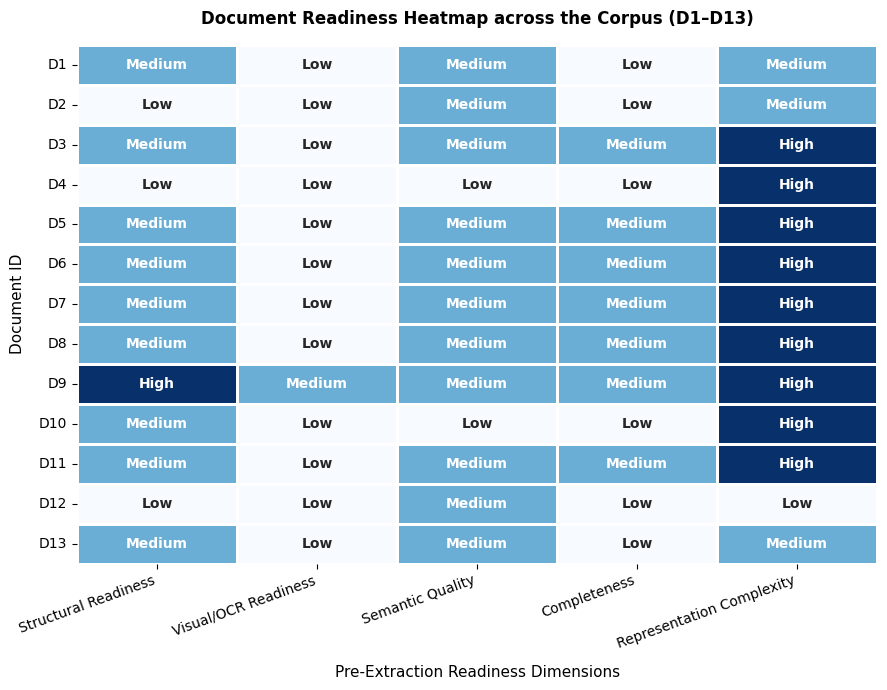

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exact scores extracted from Table 4.3
data_table_43 = {
    "Structural Readiness":     ["Medium", "Low", "Medium", "Low", "Medium", "Medium", "Medium", "Medium", "High", "Medium", "Medium", "Low", "Medium"],
    "Visual/OCR Readiness":      ["Low",    "Low",    "Low",  "Low",    "Low",  "Low",  "Low",    "Low", "Medium",  "Low", "Low", "Low", "Low"],
    "Semantic Quality":          ["Medium", "Medium", "Medium", "Low", "Medium", "Medium", "Medium",   "Medium",   "Medium", "Low", "Medium", "Medium", "Medium"],
    "Completeness":              ["Low", "Low", "Medium", "Low","Medium","Medium","Medium", "Medium", "Medium",  "Low",   "Medium", "Low", "Low"],
    "Representation Complexity": ["Medium",   "Medium", "High", "High",   "High", "High", "High", "High",   "High",  "High", "High",   "Low", "Medium"]
}

rows = [f"D{i}" for i in range(1, 14)]
df_heatmap = pd.DataFrame(data_table_43, index=rows)

mapping = {"Low": 1, "Medium": 2, "High": 3}
df_numeric = df_heatmap.replace(mapping)

plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    df_numeric,
    annot=df_heatmap,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=1.0,
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title("Document Readiness Heatmap across the Corpus (D1–D13)", fontsize=12, pad=15, fontweight='bold')
plt.xlabel("Pre-Extraction Readiness Dimensions", fontsize=11, labelpad=10)
plt.ylabel("Document ID", fontsize=11, labelpad=10)
plt.xticks(rotation=20, ha='right', fontweight='medium')
plt.yticks(rotation=0, fontweight='medium')
plt.tight_layout()


plt.savefig("document_readiness_heatmap.png", dpi=300)
plt.show()

# Figure 4.2: Exact record-level F1 across the three document representation pathway

,Document,Branch A,Branch B,Branch C
0,D1,1.000,1.000,1.000
1,D2,1.000,1.000,1.000
2,D3,0.803,0.569,0.556
3,D4,NaN,NaN,0.976
4,D5,0.636,0.733,0.667
5,D6,1.000,0.694,0.503
6,D7,0.898,0.136,0.185
7,D8,1.000,0.286,0.286
8,D9,0.737,0.263,NaN
9,D10,0.986,0.913,0.942


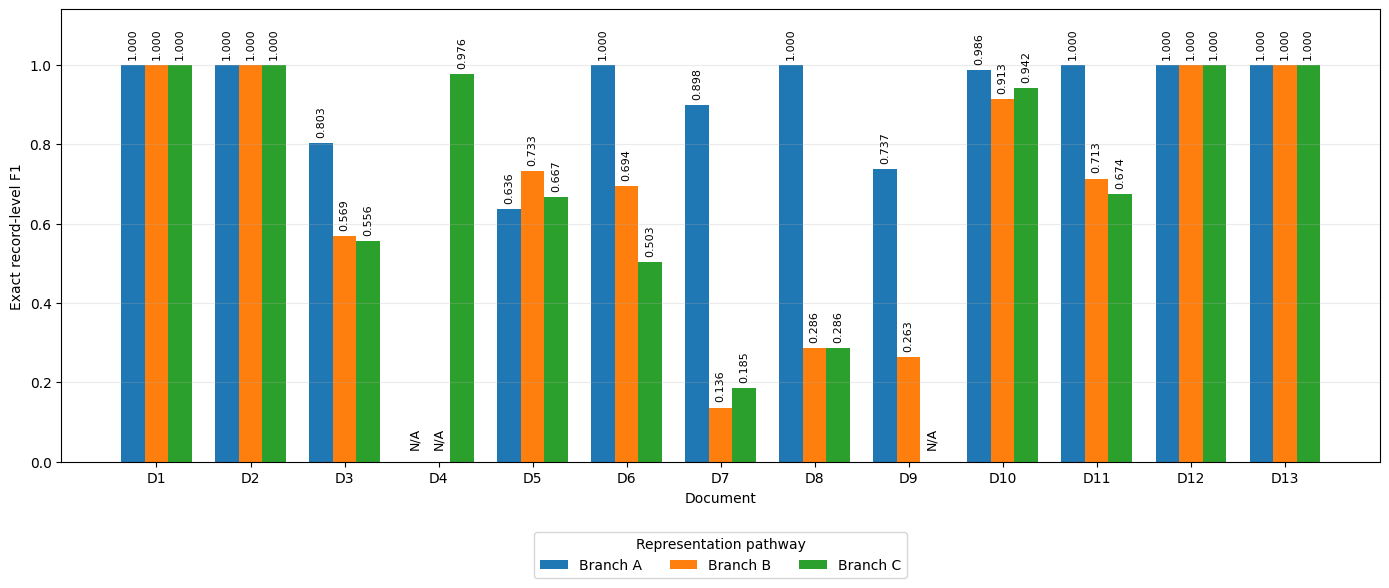

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

documents = [f"D{i}" for i in range(1, 14)]

f1_A = [
    1.000, 1.000, 0.803, np.nan, 0.636, 1.000, 0.898,
    1.000, 0.737, 0.986, 1.000, 1.000, 1.000
]

f1_B = [
    1.000, 1.000, 0.569, np.nan, 0.733, 0.694, 0.136,
    0.286, 0.263, 0.913, 0.713, 1.000, 1.000
]

f1_C = [
    1.000, 1.000, 0.556, 0.976, 0.667, 0.503, 0.185,
    0.286, np.nan, 0.942, 0.674, 1.000, 1.000
]

df = pd.DataFrame({
    "Document": documents,
    "Branch A": f1_A,
    "Branch B": f1_B,
    "Branch C": f1_C
})

display(df)

x = np.arange(len(documents))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

# Grouped bars

bars_A = ax.bar(
    x - width,
    df["Branch A"],
    width,
    label="Branch A"
)

bars_B = ax.bar(
    x,
    df["Branch B"],
    width,
    label="Branch B"
)

bars_C = ax.bar(
    x + width,
    df["Branch C"],
    width,
    label="Branch C"
)

def add_value_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.015,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

add_value_labels(ax, bars_A)
add_value_labels(ax, bars_B)
add_value_labels(ax, bars_C)


# N/A markers
# D4 - Branch A
ax.text(
    x[3] - width,
    0.03,
    "N/A",
    ha="center",
    va="bottom",
    rotation=90,
    fontsize=9
)

# D4 - Branch B
ax.text(
    x[3],
    0.03,
    "N/A",
    ha="center",
    va="bottom",
    rotation=90,
    fontsize=9
)

# D9 - Branch C
ax.text(
    x[8] + width,
    0.03,
    "N/A",
    ha="center",
    va="bottom",
    rotation=90,
    fontsize=9
)

# Axes and formatting

ax.set_xlabel("Document")
ax.set_ylabel("Exact record-level F1")

ax.set_xticks(x)
ax.set_xticklabels(documents)

ax.set_ylim(0, 1.14)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    title="Representation pathway",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14)
)

plt.tight_layout()

plt.savefig(
    "exact_f1_across_representation_pathways.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exact_f1_across_representation_pathways.pdf",
    bbox_inches="tight"
)

plt.show()

# Figure 4.3: Change in exact record-level F1 relative to Branch A

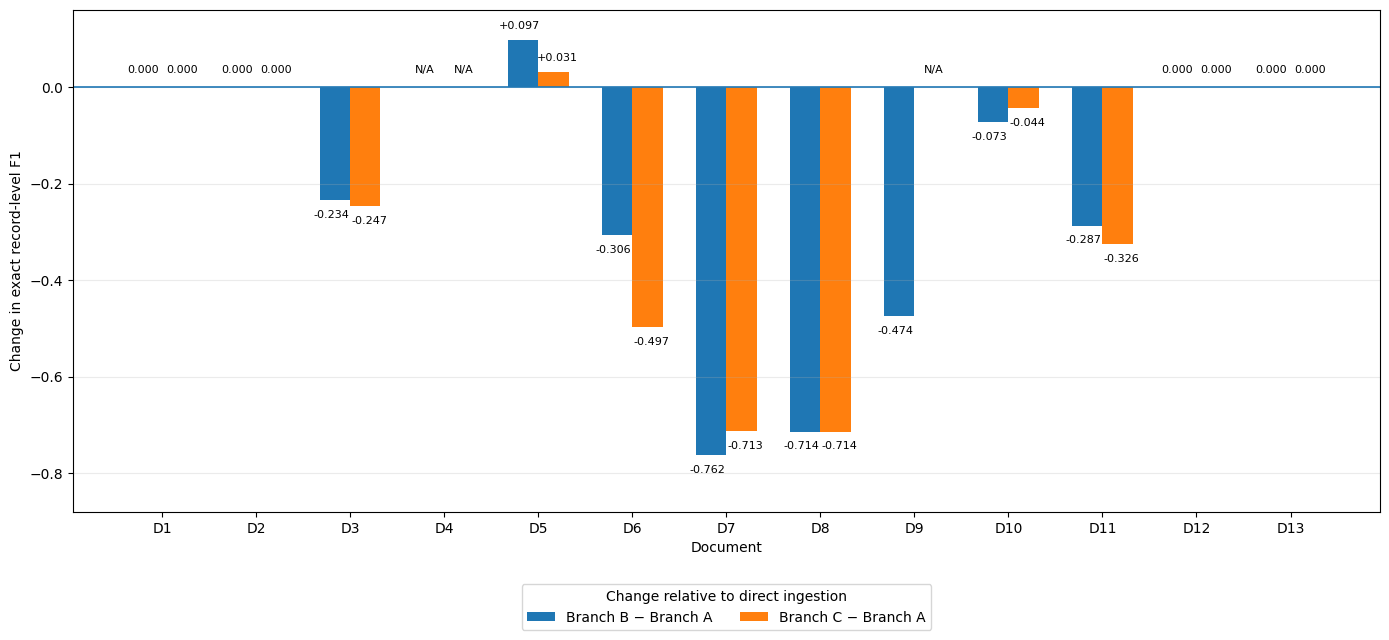

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

documents = [
    "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "D8", "D9", "D10", "D11", "D12", "D13"
]

branch_a = np.array([
    1.000, 1.000, 0.803, np.nan, 0.636, 1.000, 0.898,
    1.000, 0.737, 0.986, 1.000, 1.000, 1.000
])

branch_b = np.array([
    1.000, 1.000, 0.569, np.nan, 0.733, 0.694, 0.136,
    0.286, 0.263, 0.913, 0.713, 1.000, 1.000
])

branch_c = np.array([
    1.000, 1.000, 0.556, 0.976, 0.667, 0.503, 0.185,
    0.286, np.nan, 0.942, 0.674, 1.000, 1.000
])

delta_b = branch_b - branch_a
delta_c = branch_c - branch_a

x = np.arange(len(documents))
width = 0.32

fig, ax = plt.subplots(figsize=(14, 6.5))

# Bars
bars_b = ax.bar(
    x - width / 2,
    delta_b,
    width,
    label="Branch B − Branch A"
)

bars_c = ax.bar(
    x + width / 2,
    delta_c,
    width,
    label="Branch C − Branch A"
)

# Zero reference line
ax.axhline(
    0,
    linewidth=1.2
)

# Value labels
def add_labels(bars, horizontal_offset=0):

    for bar in bars:
        height = bar.get_height()

        if np.isnan(height):
            continue

        x_center = (
            bar.get_x()
            + bar.get_width() / 2
            + horizontal_offset
        )

        # Zero values
        if abs(height) < 1e-10:
            ax.text(
                x_center,
                0.025,
                "0.000",
                ha="center",
                va="bottom",
                fontsize=8
            )

        # Positive values
        elif height > 0:
            ax.text(
                x_center,
                height + 0.020,
                f"+{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        # Negative values
        else:
            ax.text(
                x_center,
                height - 0.020,
                f"{height:.3f}",
                ha="center",
                va="top",
                fontsize=8
            )


add_labels(
    bars_b,
    horizontal_offset=-0.045
)


add_labels(
    bars_c,
    horizontal_offset=0.045
)

# N/A markers
# D4 — Branch B vs A
ax.text(
    x[3] - width / 2 - 0.045,
    0.025,
    "N/A",
    ha="center",
    va="bottom",
    fontsize=8
)

# D4 — Branch C vs A
ax.text(
    x[3] + width / 2 + 0.045,
    0.025,
    "N/A",
    ha="center",
    va="bottom",
    fontsize=8
)

# D9 — Branch C vs A
ax.text(
    x[8] + width / 2 + 0.045,
    0.025,
    "N/A",
    ha="center",
    va="bottom",
    fontsize=8
)

# Axes
ax.set_xlabel("Document", fontsize=10)
ax.set_ylabel("Change in exact record-level F1", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(documents)


ax.set_ylim(-0.88, 0.16)

# Grid
ax.grid(
    axis="y",
    alpha=0.25
)


# Legend
ax.legend(
    title="Change relative to direct ingestion",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "delta_f1_relative_to_branch_a.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Figure 4.4: Field-level accuracy across the three document representation pathway

,Document,Branch A,Branch B,Branch C
0,D1,1.000,1.000,1.000
1,D2,1.000,1.000,1.000
2,D3,0.945,0.905,0.905
3,D4,NaN,NaN,0.994
4,D5,0.948,0.958,0.951
5,D6,1.000,0.969,0.933
6,D7,0.989,0.812,0.855
7,D8,1.000,0.851,0.885
8,D9,0.947,0.798,NaN
9,D10,0.997,0.983,0.988


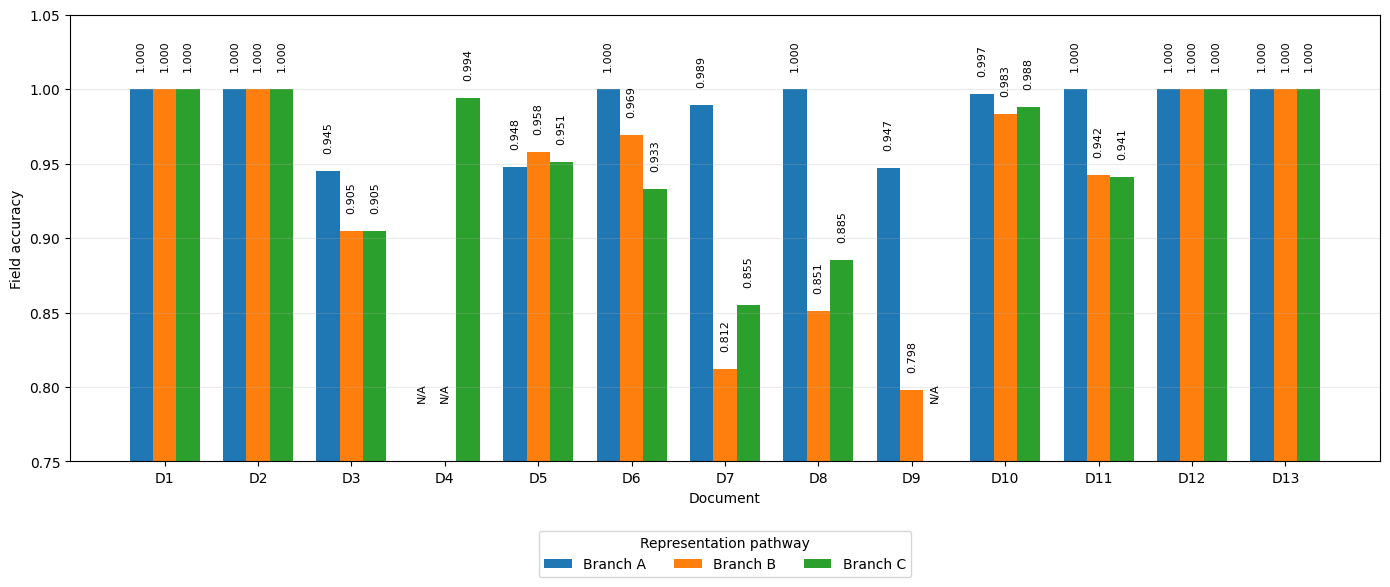

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

documents = [
    "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "D8", "D9", "D10", "D11", "D12", "D13"
]

field_accuracy_A = [
    1.000, 1.000, 0.945, np.nan, 0.948, 1.000, 0.989,
    1.000, 0.947, 0.997, 1.000, 1.000, 1.000
]

field_accuracy_B = [
    1.000, 1.000, 0.905, np.nan, 0.958, 0.969, 0.812,
    0.851, 0.798, 0.983, 0.942, 1.000, 1.000
]

field_accuracy_C = [
    1.000, 1.000, 0.905, 0.994, 0.951, 0.933, 0.855,
    0.885, np.nan, 0.988, 0.941, 1.000, 1.000
]

df = pd.DataFrame({
    "Document": documents,
    "Branch A": field_accuracy_A,
    "Branch B": field_accuracy_B,
    "Branch C": field_accuracy_C
})

display(df)

x = np.arange(len(documents))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

# Grouped bars

bars_A = ax.bar(
    x - width,
    df["Branch A"],
    width,
    label="Branch A"
)

bars_B = ax.bar(
    x,
    df["Branch B"],
    width,
    label="Branch B"
)

bars_C = ax.bar(
    x + width,
    df["Branch C"],
    width,
    label="Branch C"
)

# Value labels

def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.012,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

add_value_labels(bars_A)
add_value_labels(bars_B)
add_value_labels(bars_C)

# N/A markers
# D4 - Branch A
ax.text(
    x[3] - width,
    0.79,
    "N/A",
    ha="center",
    va="bottom",
    fontsize=8,
    rotation=90
)

# D4 - Branch B
ax.text(
    x[3],
    0.79,
    "N/A",
    ha="center",
    va="bottom",
    fontsize=8,
    rotation=90
)

# D9 - Branch C
ax.text(
    x[8] + width,
    0.79,
    "N/A",
    ha="center",
    va="bottom",
    fontsize=8,
    rotation=90
)

# Axes and formatting
ax.set_xlabel("Document")
ax.set_ylabel("Field accuracy")

ax.set_xticks(x)
ax.set_xticklabels(documents)


ax.set_ylim(0.75, 1.05)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    title="Representation pathway",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14)
)

plt.tight_layout()

plt.savefig(
    "field_accuracy_across_representation_pathways.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "field_accuracy_across_representation_pathways.pdf",
    bbox_inches="tight"
)

plt.show()